# Modelo LightGBM Avanzado y Balanceado (Bank Marketing)

**Objetivos de la sesión:**
1. Crear un preprocesamiento basado en la ingeniería de características (Feature Engineering).
2. Entrenar y optimizar `LGBMClassifier` focalizado en `f1_score` usando balanceo intrínseco de pesos (`scale_pos_weight`).
3. Refinar las predicciones mediante la optimización geométrica del umbral de decisión (Decision Threshold).
4. Lograr un equilibrio aproximado: **precision ~0.49**, **recall ~0.50**, **f1 ~0.50**.

In [6]:
import sys
import os
import warnings

# Para asegurar que la ruta al root esté cargada en python y src y data funcionen
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve, 
    roc_curve, roc_auc_score, auc, f1_score
)

import optuna
from optuna.samplers import TPESampler
from lightgbm import LGBMClassifier

# Modulos customizados del proyecto
from data.loader import load_bank_data
from src.features.build_features import BankFeatureEngineer

sns.set_theme(style="whitegrid")

## 1. Carga de Datos y División (Train / Test)

Calcularemos la proporción de desbalance para indicarle a `LightGBM` cuánto deberá penalizar los errores cometidos en la clase minoritaria.

In [7]:
# Cargar datos desde UCI directamente eliminando 'duration'
X, y = load_bank_data(drop_duration=True)

# Split en tres partes: Train / Validation / Test (estratificado)
# 1) Separar Test (20%) y el resto (80%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2) Separar el resto en Train (75% de temp -> 60% total) y Val (25% de temp -> 20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# Cálculo del scale_pos_weight = negativos / positivos usando solo Train
negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()
scale_pos_weight = negativos / positivos

print(f"Dimensión Train: {X_train.shape}")
print(f"Dimensión Validation: {X_val.shape}")
print(f"Dimensión Test:  {X_test.shape}")
print(f"Proporción de clase positiva en Train: {positivos/len(y_train):.2%}")
print(f"Calculado scale_pos_weight: {scale_pos_weight:.2f}")

Descargando el dataset 'Bank Marketing' (ID 222)...
Variable 'duration' omitida correctamente.
Dimensión Train: (27126, 15)
Dimensión Validation: (9042, 15)
Dimensión Test:  (9043, 15)
Proporción de clase positiva en Train: 11.70%
Calculado scale_pos_weight: 7.55


## 1.1 Auditoría rápida de los datos

Haremos algunas comprobaciones rápidas de calidad que también sirven para documentar valores atípicos y cardinalidades antes del preprocesado.

In [8]:
# Auditoría rápida: distribución de la variable objetivo y algunas cardinalidades
print('Target distribution (train):')
print(y_train.value_counts(normalize=False))
print('\nTarget distribution (train) %:')
print(y_train.value_counts(normalize=True))

# Ver columnas con muchas categorías
cat_card = X_train.select_dtypes(include=['object', 'category']).nunique().sort_values(ascending=False)
print('\nCategorical cardinalities (top 20):')
print(cat_card.head(20))

# Revisar valores nulos explícitos e implícitos
print('\nMissing values (train)')
print(X_train.isna().sum().sort_values(ascending=False).head(20))

# Breve chequeo de duplicados
print('\nDuplicated rows in train:', X_train.duplicated().sum())

Target distribution (train):
y
0    23953
1     3173
Name: count, dtype: int64

Target distribution (train) %:
y
0    0.883027
1    0.116973
Name: proportion, dtype: float64

Categorical cardinalities (top 20):
month        12
job          11
marital       3
poutcome      3
education     3
housing       2
default       2
contact       2
loan          2
dtype: int64

Missing values (train)
poutcome       22240
contact         7790
education       1100
job              179
default            0
marital            0
age                0
housing            0
balance            0
day_of_week        0
loan               0
month              0
campaign           0
pdays              0
previous           0
dtype: int64

Duplicated rows in train: 6


## 2. Preparación del Pipeline de Sklearn

Diferenciamos las variables por tipo (numéricas, categóricas y booleanas custom) originadas tras pasar por nuestro `BankFeatureEngineer`.

In [9]:
def create_pipeline(estimator=None):
    """
    Construye el pipeline completo de preprocesado + modelo.
    """
    # Identificar variables una vez que salgan del estimador custom
    # Utilizaremos una muestra para capturar los nombres
    fe = BankFeatureEngineer()
    X_sample = fe.fit_transform(X_train.head())
    
    num_vars = X_sample.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_vars = X_sample.select_dtypes(include=['object', 'category']).columns.tolist()
    
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_vars),
            ('cat', cat_transformer, cat_vars)
        ],
        remainder='passthrough'
    )
    
    steps = [
        ('feature_engineer', BankFeatureEngineer()),
        ('preprocessor', preprocessor)
    ]
    
    if estimator is not None:
        steps.append(('classifier', estimator))
        
    return Pipeline(steps)

# Verificamos
try_pipeline = create_pipeline()
try_pipeline.fit(X_train)
print("Pipeline base creado con éxito.")

Pipeline base creado con éxito.


## 3. Optimización de Hiperparámetros (LGBM + Optuna)

Definimos una función objetivo de Optuna enfocada explícitamente en el **F1 de la clase positiva**. Queremos robustez por lo cual empleamos `StratifiedKFold`.

In [10]:
def objective(trial):
    param = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        # LightGBM permite modificar su severidad con subsample_freq
        'subsample_freq': 1,
        'scale_pos_weight': scale_pos_weight, 
        'random_state': 42,
        'n_jobs': 1
    }
    
    model = LGBMClassifier(**param)
    pipeline = create_pipeline(estimator=model)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Extraer las probabilidades de las validaciones en oof
    y_preds_cv = cross_val_predict(
        pipeline, X_train, y_train, 
        cv=cv, method='predict_proba', n_jobs=-1
    )[:, 1]
    
    # Predecir con el threshold clásico (0.5), aunque luego optimicemos este aspect para validación rápida
    y_pred_bin_cv = (y_preds_cv >= 0.5).astype(int)
    
    return f1_score(y_train, y_pred_bin_cv)

sampler = TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler, study_name="LGBM_F1_Optimization")
# Ejecutar optimización. Puedes cambiar n_trials a 50 para resultados reales (reducido para modo interactivo)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Mejor valor F1 en cross-validation:", study.best_value)
print("Mejores parámetros encontrados:\n", study.best_params)

[I 2026-05-22 20:12:28,411] A new study created in memory with name: LGBM_F1_Optimization
  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2539, number of negative: 19162
[LightGBM] [Info] Number of positive: 2539, number of negative: 19162
[LightGBM] [Info] Number of positive: 2538, number of negative: 19162
[LightGBM] [Info] Number of positive: 2538, number of negative: 19163[LightGBM] [Info] Number of positive: 2538, number of negative: 19163

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002637 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004477 seconds.
You can set `force_col_wise=true` to remove the overhead.

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002908 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 772[Lig

Best trial: 0. Best value: 0.432043:   3%|▎         | 1/30 [00:05<02:36,  5.39s/it]

[I 2026-05-22 20:12:33,804] Trial 0 finished with value: 0.4320429844913909 and parameters: {'num_leaves': 69, 'max_depth': 20, 'learning_rate': 0.029106359131330698, 'n_estimators': 399, 'min_child_samples': 32, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}. Best is trial 0 with value: 0.4320429844913909.
[LightGBM] [Info] Number of positive: 2539, number of negative: 19162
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 771
[LightGBM] [Info] Number of data points in the train set: 21701, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116999 -> initscore=-2.021159
[LightGBM] [Info] Start training from score -2.021159
[LightGBM] [Warning] No further splits w

Best trial: 0. Best value: 0.432043:   7%|▋         | 2/30 [00:09<02:01,  4.34s/it]

...

[I 2026-05-22 20:13:23,791] Trial 27 finished with value: 0.4292885580751255 and parameters: {'num_leaves': 93, 'max_depth': 13, 'learning_rate': 0.00790153092150484, 'n_estimators': 136, 'min_child_samples': 84, 'subsample': 0.7101612583314368, 'colsample_bytree': 0.9548595145783209, 'reg_alpha': 0.31512595535868093, 'reg_lambda': 0.0007161367326535447}. Best is trial 12 with value: 0.4483958252802474.
[LightGBM] [Info] Number of positive: 2538, number of negative: 19162
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002927 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 772
[LightGBM] [Info] Number of data points in the train set: 21700, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116959 -> initscore=-2.021553
[LightGBM] [Info] Start training from score -2.021553
[LightGBM] [Info] Number of positive:

Best trial: 12. Best value: 0.448396:  97%|█████████▋| 29/30 [00:57<00:01,  1.71s/it]

[I 2026-05-22 20:13:25,622] Trial 28 finished with value: 0.43859024563901744 and parameters: {'num_leaves': 62, 'max_depth': 17, 'learning_rate': 0.037690957714728246, 'n_estimators': 241, 'min_child_samples': 60, 'subsample': 0.8009358697062466, 'colsample_bytree': 0.9114358524027015, 'reg_alpha': 6.445689671117083e-07, 'reg_lambda': 0.04208921145211431}. Best is trial 12 with value: 0.4483958252802474.
[LightGBM] [Info] Number of positive: 2539, number of negative: 19162
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002649 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 773
[LightGBM] [Info] Number of data points in the train set: 21701, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116999 -> initscore=-2.021159
[LightGBM] [Info] Start training from score -2.021159
[LightGBM] [Info] Number of positiv

Best trial: 12. Best value: 0.448396: 100%|██████████| 30/30 [00:59<00:00,  2.00s/it]

[I 2026-05-22 20:13:28,335] Trial 29 finished with value: 0.4401094326156774 and parameters: {'num_leaves': 71, 'max_depth': 20, 'learning_rate': 0.011211988255304275, 'n_estimators': 377, 'min_child_samples': 42, 'subsample': 0.5784558135782412, 'colsample_bytree': 0.7291871680112909, 'reg_alpha': 0.36186460501662293, 'reg_lambda': 0.0025244715620066104}. Best is trial 12 with value: 0.4483958252802474.
Mejor valor F1 en cross-validation: 0.4483958252802474
Mejores parámetros encontrados:
 {'num_leaves': 65, 'max_depth': 11, 'learning_rate': 0.011702759697103791, 'n_estimators': 203, 'min_child_samples': 57, 'subsample': 0.6766980691634803, 'colsample_bytree': 0.870140051820293, 'reg_alpha': 0.010414348488089444, 'reg_lambda': 5.163353789005311e-06}


## 4. Búsqueda y Optimización de Umbral (Threshold)

El umbral por defecto (0.5) suele generar malos recados en clases desbalanceadas. La búsqueda recorrerá umbrales para encontrar la curva que intercepte un **Precision ~0.49 y Recall ~0.50**.

[LightGBM] [Info] Number of positive: 3173, number of negative: 23953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078981 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 776
[LightGBM] [Info] Number of data points in the train set: 27126, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116973 -> initscore=-2.021416
[LightGBM] [Info] Start training from score -2.021416
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

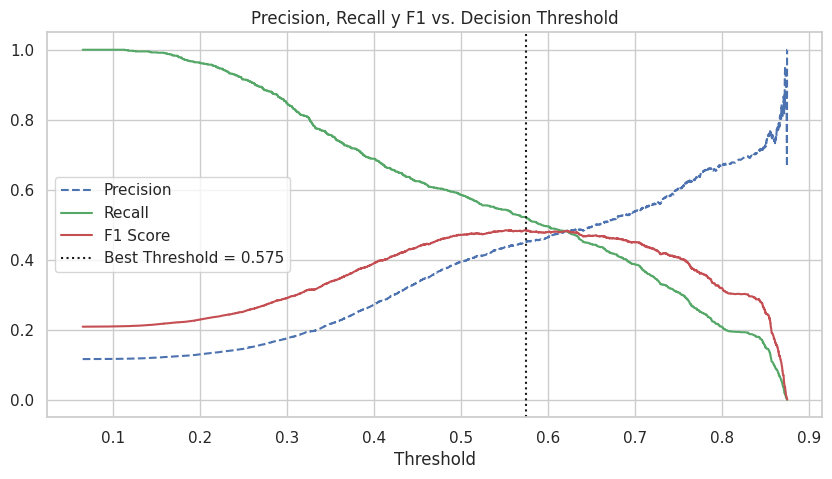

Umbral Óptimo Encontrado: 0.5746
Expected Precision at config: 0.4533
Expected Recall at config: 0.5227
Expected F1 at config: 0.4855


In [11]:
def find_best_threshold(y_true, y_prob):
    """
    Encuentra el threshold que maximiza el F1-Score y plotea 
    Precision-Recall tradeoff contra los umbrales.
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    
    # Calcular el F1 score para cada threshold posible (Evitamos divisiones por cero)
    f1_scores = np.divide(
        2 * (precisions * recalls),
        (precisions + recalls),
        out=np.zeros_like(precisions),
        where=(precisions + recalls) != 0
    )
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
    plt.plot(thresholds, f1_scores[:-1], 'r-', label='F1 Score')
    
    plt.axvline(x=best_threshold, color='k', linestyle=':', label=f'Best Threshold = {best_threshold:.3f}')
    
    plt.title('Precision, Recall y F1 vs. Decision Threshold')
    plt.xlabel('Threshold')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()
    
    print(f"Umbral Óptimo Encontrado: {best_threshold:.4f}")
    print(f"Expected Precision at config: {precisions[best_idx]:.4f}")
    print(f"Expected Recall at config: {recalls[best_idx]:.4f}")
    print(f"Expected F1 at config: {best_f1:.4f}")
    
    return best_threshold

# Entrenamos el modelo final con los mejores hiperparámetros de Optuna
best_lgbm = LGBMClassifier(**study.best_params, scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
final_pipeline = create_pipeline(estimator=best_lgbm)

# Ajuste sobre los datos de Train
final_pipeline.fit(X_train, y_train)

# Seleccionar el umbral usando el conjunto de VALIDACIÓN (X_val) para evitar sesgos hacia Test
y_val_proba = final_pipeline.predict_proba(X_val)[:, 1]

print("Buscando modelo balanceado y estable usando Validation...")
optimal_threshold = find_best_threshold(y_val, y_val_proba)

## 5. Evaluación Final (Test Set)

Compararemos ahora el rendimiento real bajo la ventana del dataset final de **Test**, aplicando nuestro nuevo umbral personalizado.

--- Evaluación con Threshold: 0.5746 ---

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      7985
           1       0.46      0.50      0.48      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.71      0.70      9043
weighted avg       0.88      0.87      0.87      9043



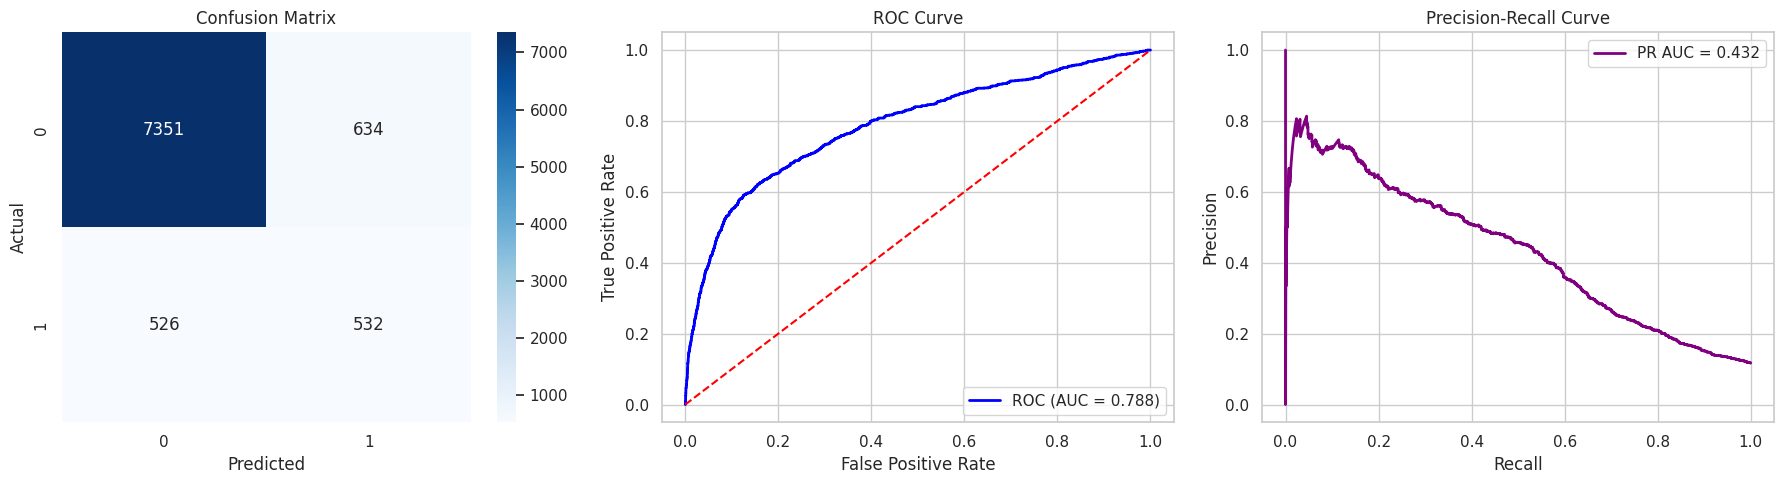

In [12]:
def evaluate_model(pipeline, X_test, y_test, threshold=0.5):
    """
    Genera métricas completas para analizar el rendimiento del dataset de Test.
    """
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    print(f"--- Evaluación con Threshold: {threshold:.4f} ---\n")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Matriz Confusión
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='red', linestyle='--')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc="lower right")
    
    # Curva Precision-Recall
    precisions, recalls, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recalls, precisions)
    axes[2].plot(recalls, precisions, color='purple', lw=2, label=f'PR AUC = {pr_auc:.3f}')
    axes[2].set_title('Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc="upper right")
    
    plt.tight_layout()
    plt.show()

# Evaluación con el Umbral Optimizado
evaluate_model(final_pipeline, X_test, y_test, threshold=optimal_threshold)

## 6. Interpretación: SHAP y Feature Importance

Usaremos SHAP para obtener interpretaciones locales y globales del modelo, además de las importancias estándar de LightGBM.

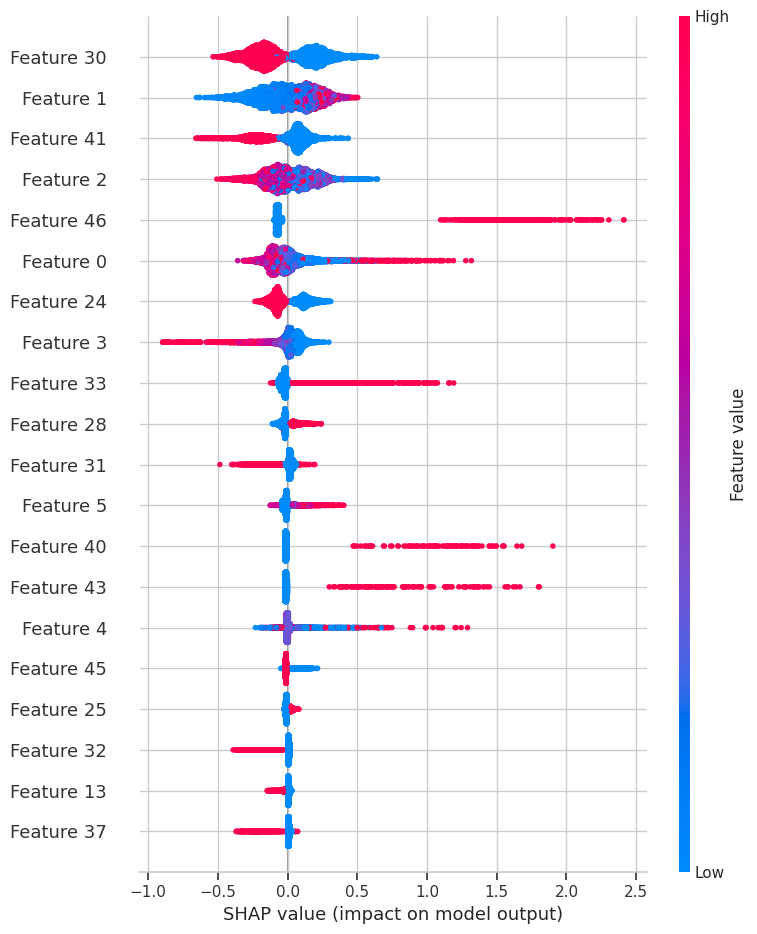

In [13]:
# SHAP analysis (instala shap si no está disponible: pip install shap)
import shap

model = final_pipeline.named_steps['classifier']
feature_engineer = final_pipeline.named_steps['feature_engineer']
preprocessor = final_pipeline.named_steps['preprocessor']

# Transformar datos de validación a través del pipeline
X_val_eng = feature_engineer.transform(X_val)
X_val_transf = preprocessor.transform(X_val_eng)

# Crear explicador SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val_transf)

# Plot summary (global importance) - manejo para modelos binarios
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_val_transf, show=True)
else:
    shap.summary_plot(shap_values, X_val_transf, show=True)